## Partial Pressure (torr) to Concentration Conversions Using RGA

In [5]:
# Dependencies
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# This cell defines all user-editable inputs for the 5 extracted compounds,
# including the target AMU, Henry's Law constant, output concentration unit,
# and the exported file names/titles that will be used later in the program.

# This is the only cell that needs to be edited if you want to extract new information

# You should also use ctrl_f for "FIGURE_OUTPUT_FOLDER" and select true if you want to export figures_ppConcentration

COMPOUND_CONFIGS = [
    {
        "compound_name": "Hydrogen",
        "mass": 2.00,
        "henrys_constant": 7.8e-4,  # mol/(L*atm)
        "final_unit": "uM",
        "output_csv": r"C:\Users\chero\OneDrive\Desktop\W2026\ESS 469\hydrogen_concentration_2017.csv"
    },
    {
        "compound_name": "Methane",
        "mass": 16.00,
        "henrys_constant": 1.4e-3,  # mol/(L*atm)
        "final_unit": "uM",
        "output_csv": r"C:\Users\chero\OneDrive\Desktop\W2026\ESS 469\methane_concentration_2017.csv"
    },
    {
        "compound_name": "Carbon_Dioxide",
        "mass": 44.00,
        "henrys_constant": 1.7e-3,  # mol/(L*atm)
        "final_unit": "uM",
        "output_csv": r"C:\Users\chero\OneDrive\Desktop\W2026\ESS 469\carbon_dioxide_concentration_2017.csv"
    },
    {
        "compound_name": "Nitrogen",
        "mass": 28.00,
        "henrys_constant": 6.5e-4,  # mol/(L*atm)
        "final_unit": "uM",
        "output_csv": r"C:\Users\chero\OneDrive\Desktop\W2026\ESS 469\nitrogen_concentration_2017.csv"
    },
    {
        "compound_name": "Oxygen",
        "mass": 32.00,
        "henrys_constant": 1.3e-3,  # mol/(L*atm)
        "final_unit": "uM",
        "output_csv": r"C:\Users\chero\OneDrive\Desktop\W2026\ESS 469\oxygen_concentration_2017.csv"
    },
    {
        "compound_name": "Hydrogen Sulfide",
        "mass": 34.00,
        "henrys_constant": 1.0e-1,  # mol/(L*atm)
        "final_unit": "mM",
        "output_csv": r"C:\Users\chero\OneDrive\Desktop\W2026\ESS 469\oxygen_concentration_2017.csv"
    }
]

# Modify this for your path with your files
DATA_PATH = r"C:\Users\chero\Downloads\MASSPA_2017_Time_Series_Ready.csv"
FIGURE_OUTPUT_FOLDER = r"figures_ppConcentration/pp_concentrationFigures"
DISPLAY_DATAFRAME = False

In [7]:
# Extraction and conversions
# Read the original mass spectrometry time series file
masspa_df = pd.read_csv(DATA_PATH)

if DISPLAY_DATAFRAME:
    display(masspa_df)

# How many unique values are there in the 'Timestamp' column?
unique_timestamps = masspa_df['Timestamp'].nunique()
print(f'Number of unique timestamps: {unique_timestamps}')

# How many unique days are there in the 'Timestamp' column?
masspa_df['Date'] = pd.to_datetime(masspa_df['Timestamp']).dt.date
unique_days = masspa_df['Date'].nunique()
print(f'Number of unique days: {unique_days}')

# Make a new dataframe with a row for each unique timestamp
# From the original dataframe, for each row with the same timestamp,
# sum the 'Partial_Pressure' and save as 'Total_Pressure' in the new dataframe
base_df = masspa_df.groupby('Timestamp').agg(
    Total_Pressure=('Partial_Pressure', 'sum')
).reset_index()

# Add new column extracting useful date and time from Timestamp for plotting
base_df['Date'] = pd.to_datetime(base_df['Timestamp']).dt.date
base_df['Time'] = pd.to_datetime(base_df['Timestamp']).dt.time

# Create a proper datetime column for plotting
base_df['DateTime'] = pd.to_datetime(base_df['Timestamp'])

# Build a conversion dictionary so the user can request final output in
# mol/L, mM, uM, nM, or pM while keeping the Henry's Law calculation in mol/L first
unit_multipliers = {
    "mol/L": 1,
    "mM": 1e3,
    "uM": 1e6,
    "nM": 1e9,
    "pM": 1e12
}

# Next, we will do some simple aqueous chemistry
# to convert from the extracted gas partial pressure and Total_Pressure
# to a dissolved concentration in a user-selected concentration unit
# We will use Henry's Law, which states that the concentration of a gas in a liquid is proportional to the partial pressure of the gas above the liquid
# The proportionality constant is called the Henry's Law constant, and it must be provided separately for each compound
# Then convert using Henry's Law: C = kH * P, where C is the concentration in mol/L, kH is the Henry's Law constant, and P is the gas fraction expressed here as partial pressure / total pressure

compound_results = {}

for config in COMPOUND_CONFIGS:
    compound_name = config["compound_name"]
    target_mass = config["mass"]
    henrys_constant = config["henrys_constant"]
    final_unit = config["final_unit"]

    new_df = base_df.copy()

    # From the original dataframe, for each timestamp,
    # pick out the value of 'Partial_Pressure' where the values of 'Mass' equal the target AMU,
    # and save as '<Compound>_Pressure' in the new dataframe
    pressure_col = f'{compound_name}_Pressure'
    concentration_col = f'{compound_name}_Concentration_{final_unit}'

    extracted_pressure = masspa_df.groupby('Timestamp').apply(
        lambda group: group.loc[group['Mass'] == target_mass, 'Partial_Pressure'].sum()
    ).reset_index(name=pressure_col)

    new_df = new_df.merge(extracted_pressure, on='Timestamp', how='left')
    new_df[pressure_col] = new_df[pressure_col].fillna(0)

    # Then convert using Henry's Law: C = kH * P
    # First calculate concentration in mol/L, then scale to the final requested unit
    new_df[concentration_col] = (
            (new_df[pressure_col] / new_df['Total_Pressure']) *
            henrys_constant *
            unit_multipliers[final_unit]
    )

    compound_results[compound_name] = {
        "dataframe": new_df,
        "pressure_col": pressure_col,
        "concentration_col": concentration_col,
        "final_unit": final_unit,
        "output_csv": config["output_csv"]
    }

    # Find the maximum of the concentration column
    max_concentration = new_df[concentration_col].max()
    print(f'Maximum {compound_name} concentration: {max_concentration} {final_unit}')

    # And the minimum
    min_concentration = new_df[concentration_col].min()
    print(f'Minimum {compound_name} concentration: {min_concentration} {final_unit}')

    # And the average
    average_concentration = new_df[concentration_col].mean()
    print(f'Average {compound_name} concentration: {average_concentration} {final_unit}')

Number of unique timestamps: 29770
Number of unique days: 23


C:\Users\chero\AppData\Local\Temp\ipykernel_18276\2775271252.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  extracted_pressure = masspa_df.groupby('Timestamp').apply(


Maximum Hydrogen concentration: 40.32213741936797 uM
Minimum Hydrogen concentration: 0.023160455788830126 uM
Average Hydrogen concentration: 4.7094947967875775 uM


C:\Users\chero\AppData\Local\Temp\ipykernel_18276\2775271252.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  extracted_pressure = masspa_df.groupby('Timestamp').apply(


Maximum Methane concentration: 10.918718375216514 uM
Minimum Methane concentration: 0.05344965909303657 uM
Average Methane concentration: 2.0624232006546017 uM


...

C:\Users\chero\AppData\Local\Temp\ipykernel_18276\2775271252.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  extracted_pressure = masspa_df.groupby('Timestamp').apply(


Maximum Nitrogen concentration: 73.58452243568121 uM
Minimum Nitrogen concentration: 0.01577058622690145 uM
Average Nitrogen concentration: 47.083041068364246 uM


C:\Users\chero\AppData\Local\Temp\ipykernel_18276\2775271252.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  extracted_pressure = masspa_df.groupby('Timestamp').apply(


Maximum Oxygen concentration: 114.65143657757619 uM
Minimum Oxygen concentration: 0.03629877947197429 uM
Average Oxygen concentration: 21.057414155698066 uM
Maximum Hydrogen Sulfide concentration: 0.6008489772035713 mM
Minimum Hydrogen Sulfide concentration: -0.015689011384582865 mM
Average Hydrogen Sulfide concentration: 0.006995682011902731 mM


C:\Users\chero\AppData\Local\Temp\ipykernel_18276\2775271252.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  extracted_pressure = masspa_df.groupby('Timestamp').apply(


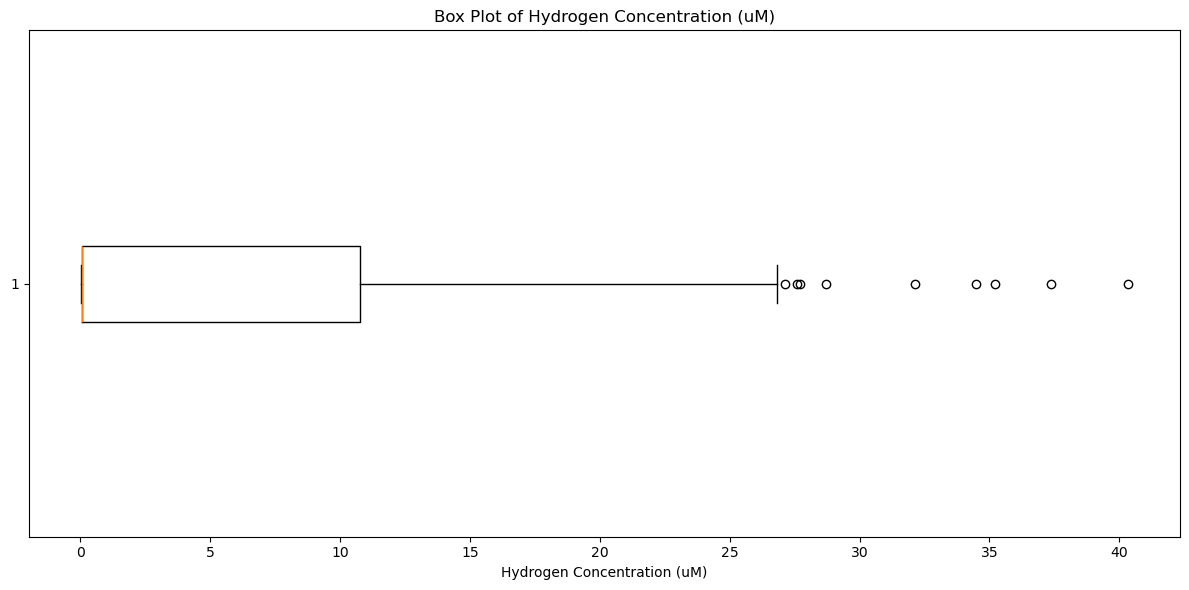

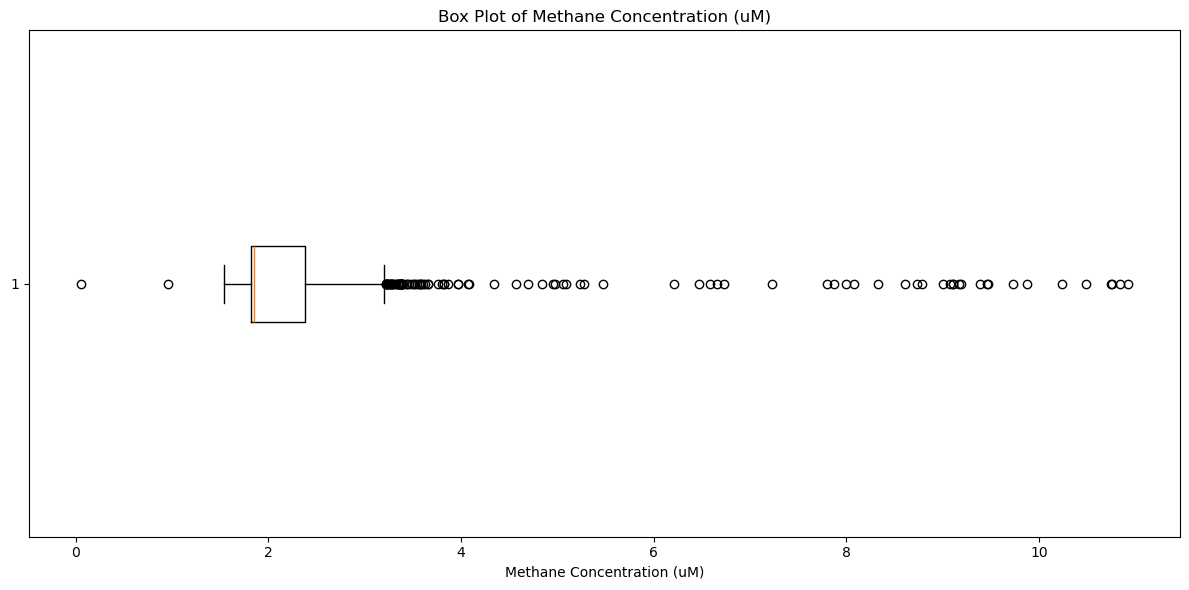

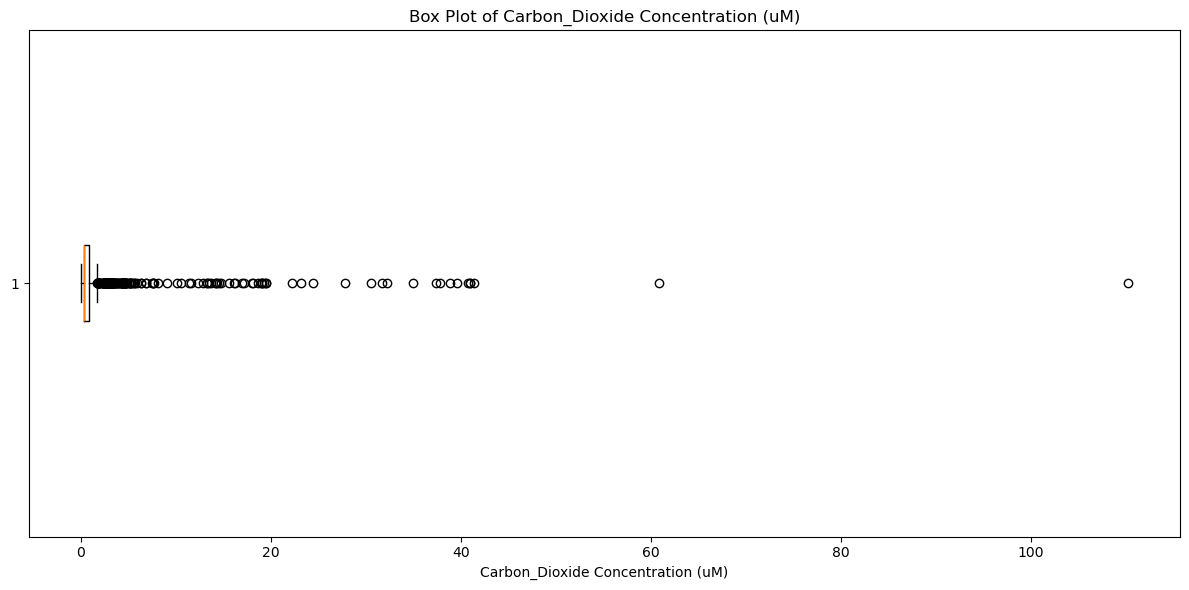

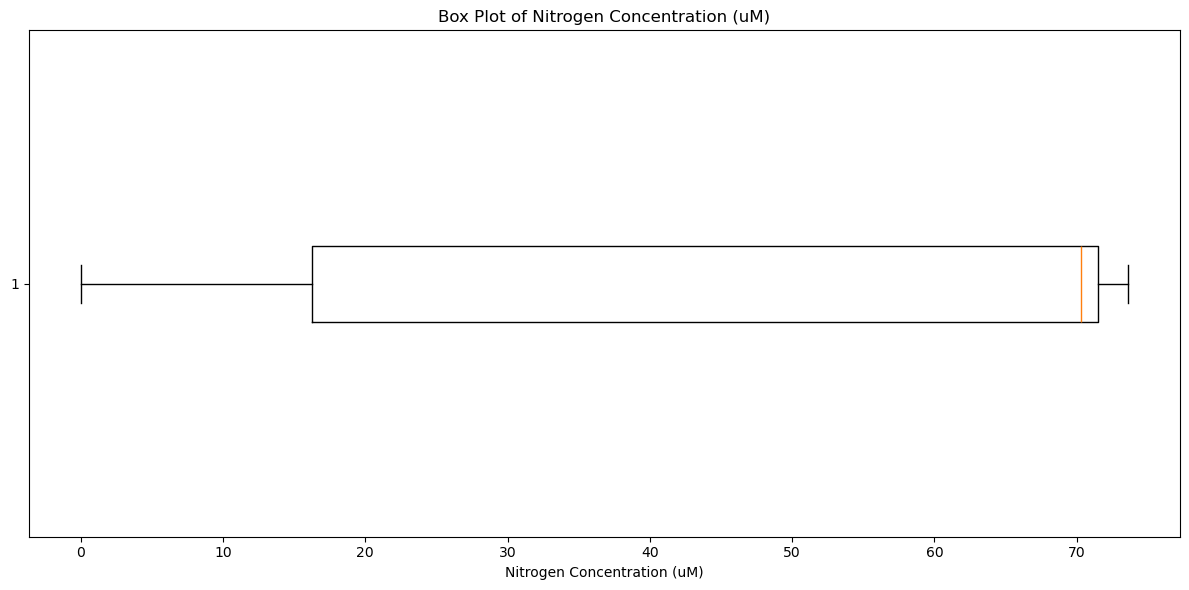

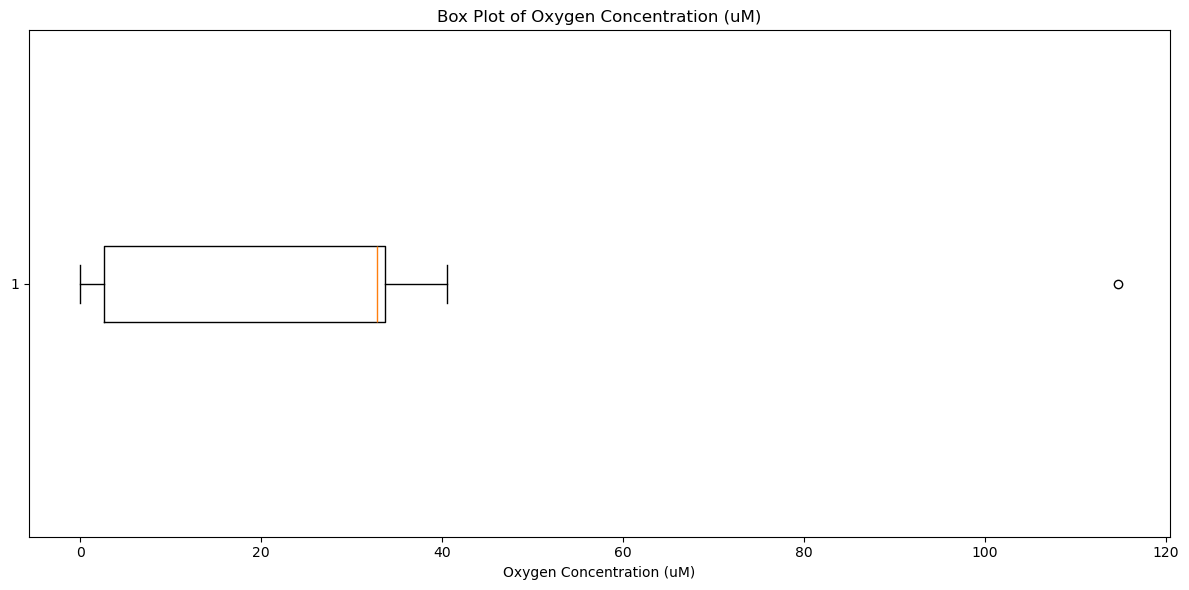

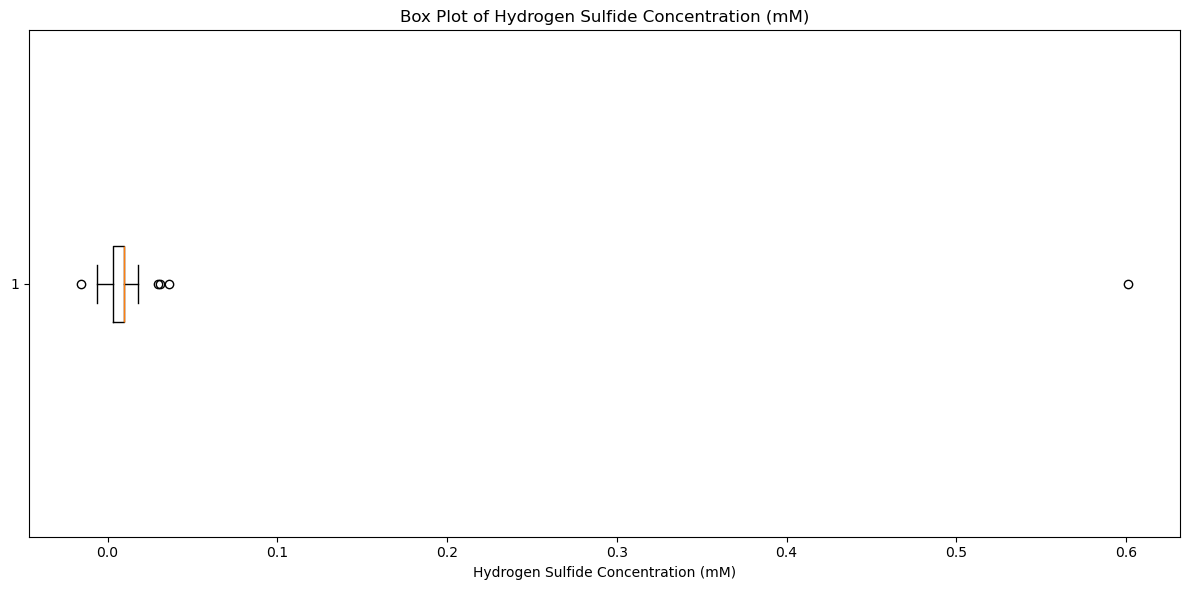

In [8]:
# Figure 1
# Box plot of concentration for each extracted compound

for compound_name, result in compound_results.items():
    new_df = result["dataframe"]
    concentration_col = result["concentration_col"]
    final_unit = result["final_unit"]

    plt.figure(figsize=(12, 6))
    plt.boxplot(new_df[concentration_col], vert=False)
    plt.title(f'Box Plot of {compound_name} Concentration ({final_unit})')
    plt.xlabel(f'{compound_name} Concentration ({final_unit})')
    plt.tight_layout()
    plt.show()

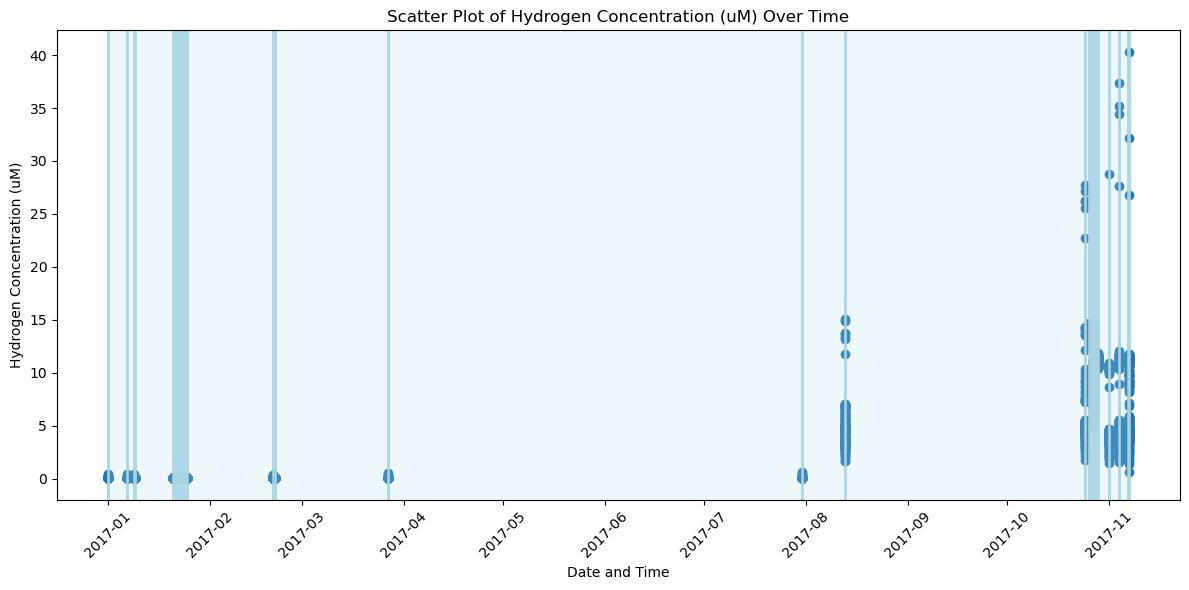

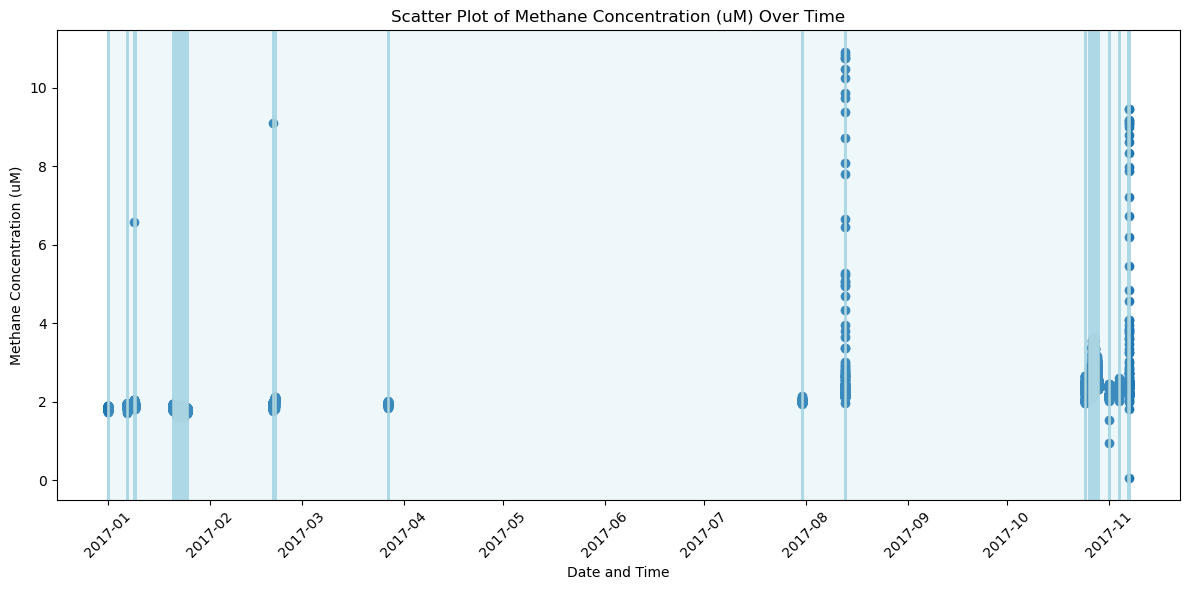

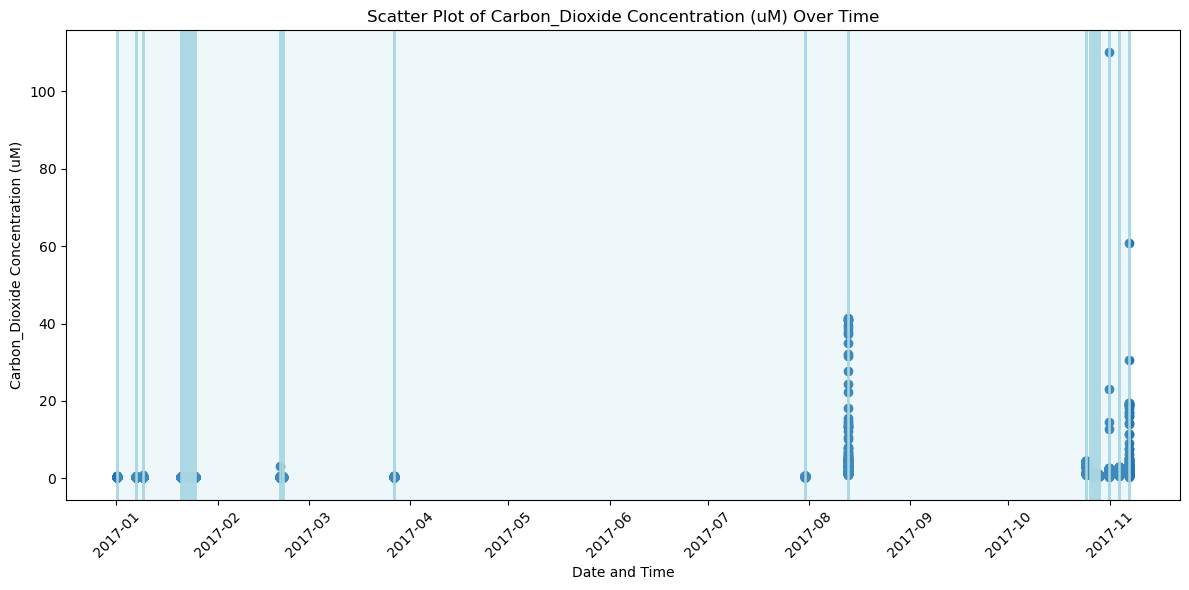

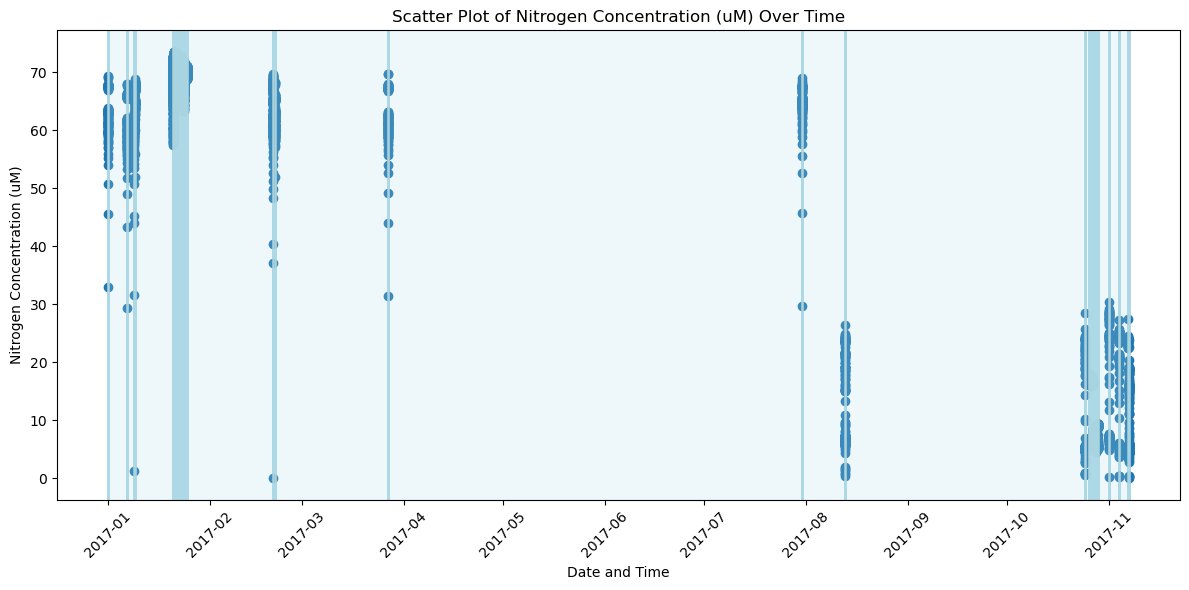

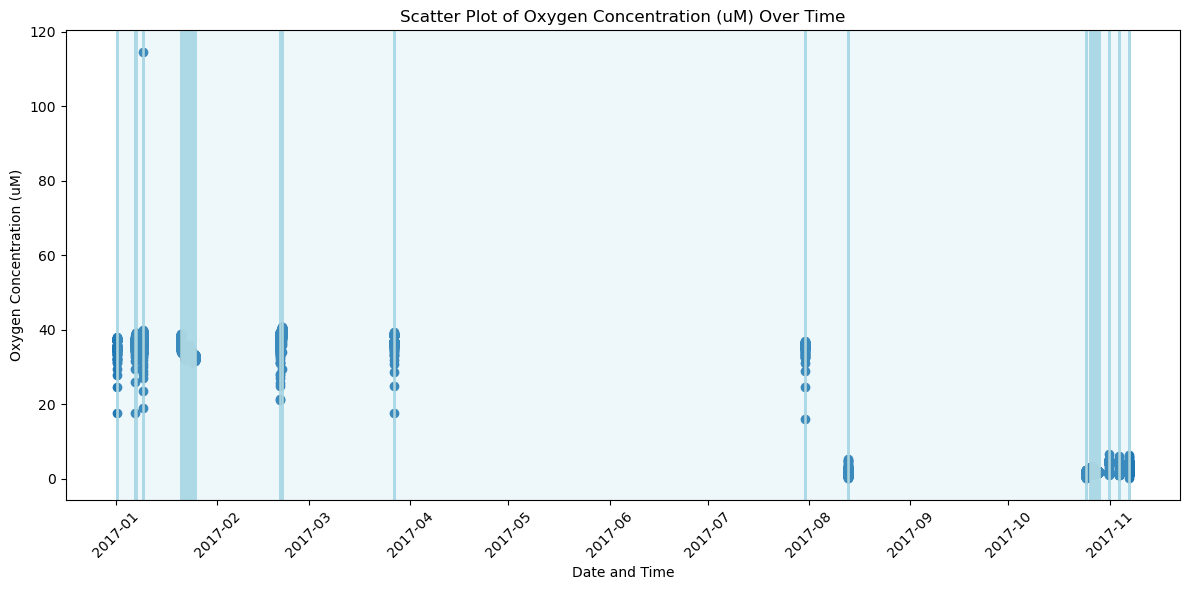

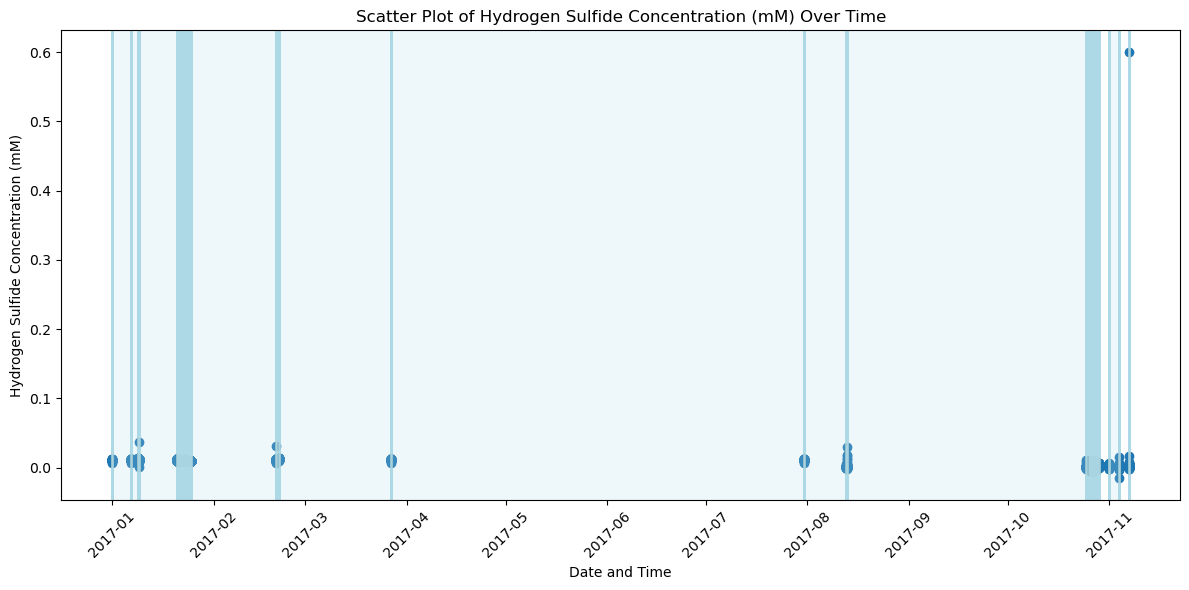

In [9]:
# Figure 2
# Plot scatter plot of Date + Time vs. concentration for each extracted compound
# Add transparent windows highlighting regions for which we have data

for compound_name, result in compound_results.items():
    new_df = result["dataframe"]
    concentration_col = result["concentration_col"]
    final_unit = result["final_unit"]

    plt.figure(figsize=(12, 6))
    plt.scatter(new_df['DateTime'], new_df[concentration_col])

    for i in range(len(new_df) - 1):
        if new_df.iloc[i][concentration_col] > 0 and new_df.iloc[i + 1][concentration_col] > 0:
            plt.axvspan(
                new_df.iloc[i]['DateTime'],
                new_df.iloc[i + 1]['DateTime'],
                alpha=0.2,
                color='lightblue'
            )

    plt.title(f'Scatter Plot of {compound_name} Concentration ({final_unit}) Over Time')
    plt.xlabel('Date and Time')
    plt.ylabel(f'{compound_name} Concentration ({final_unit})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

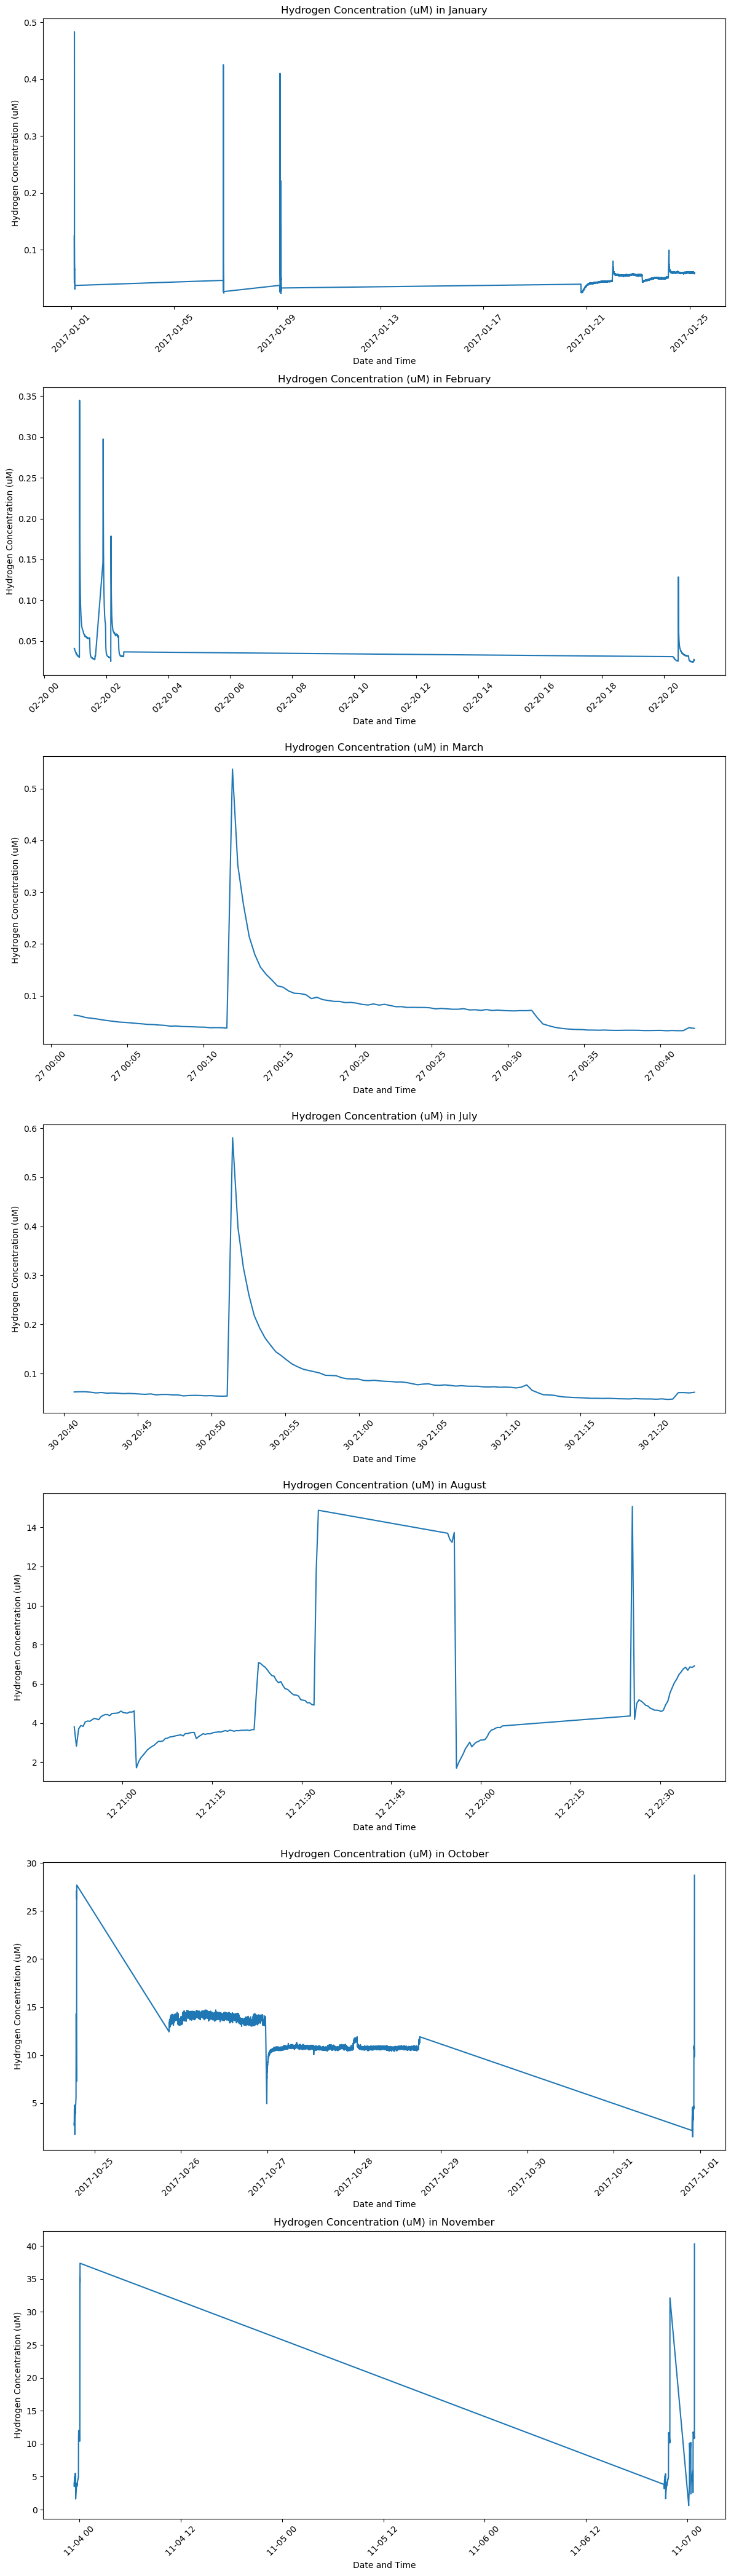

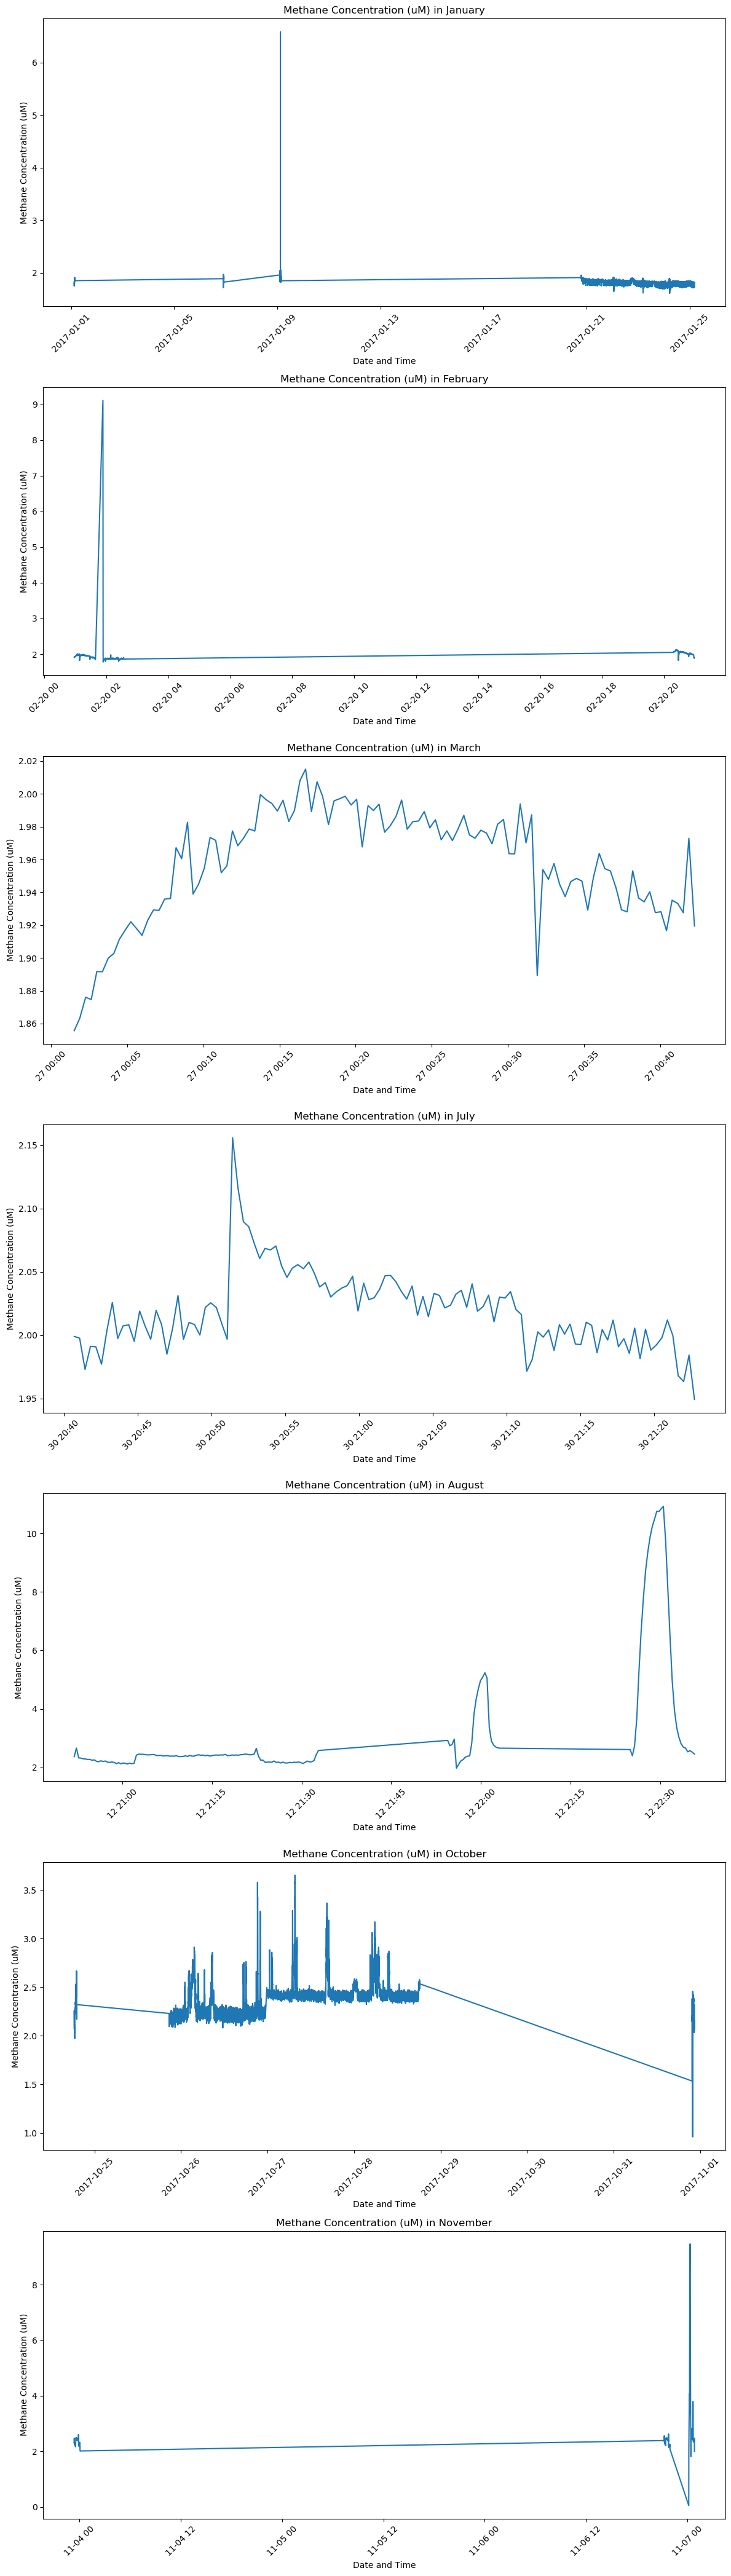

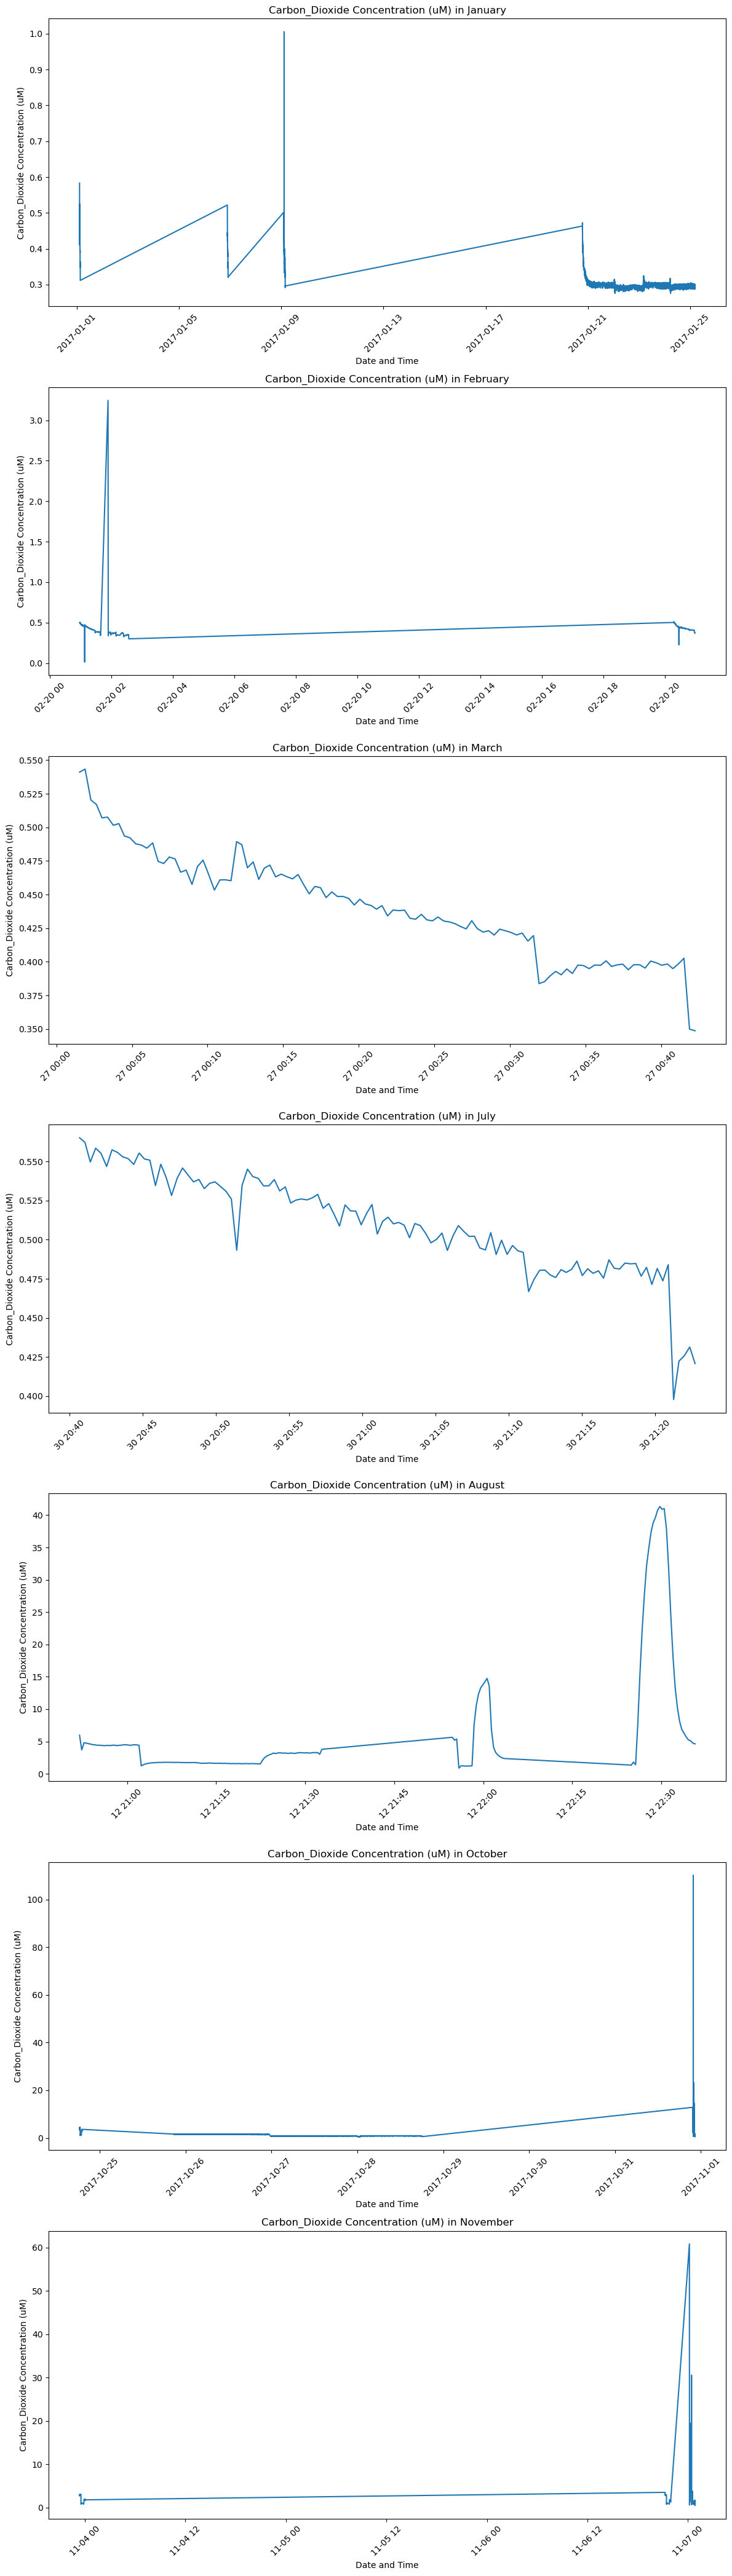

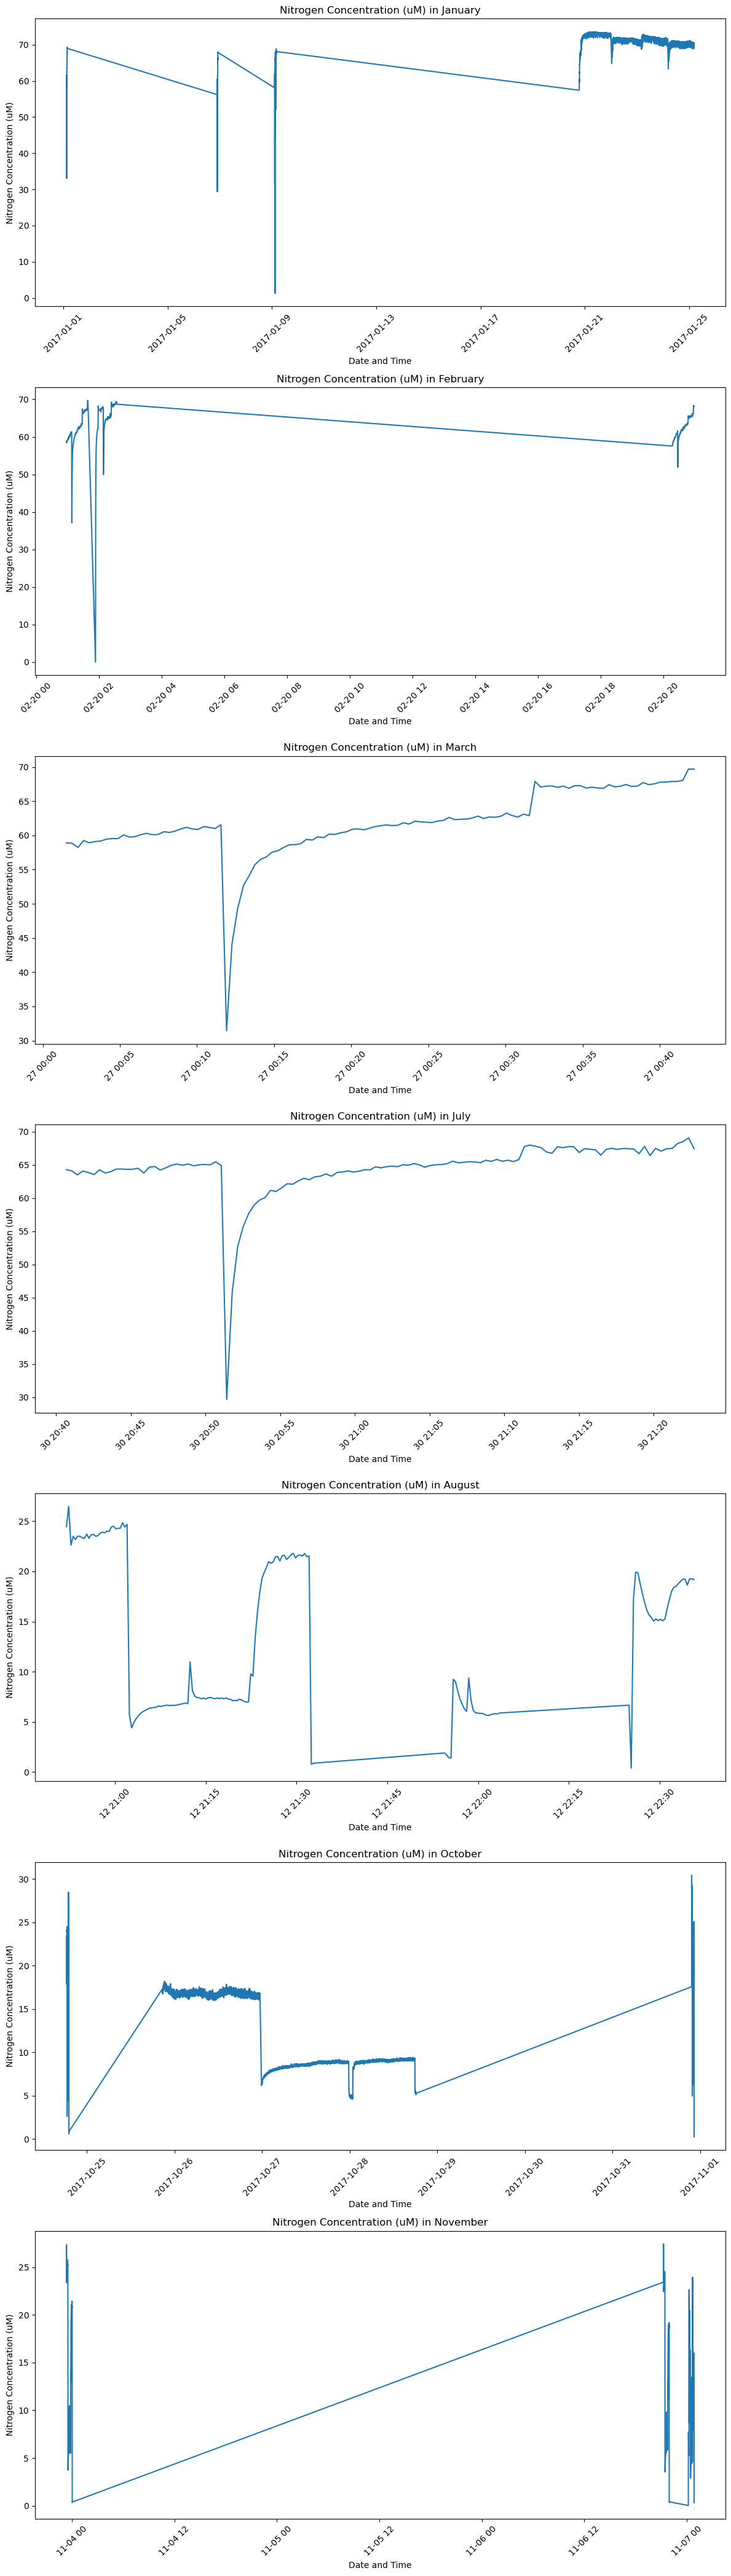

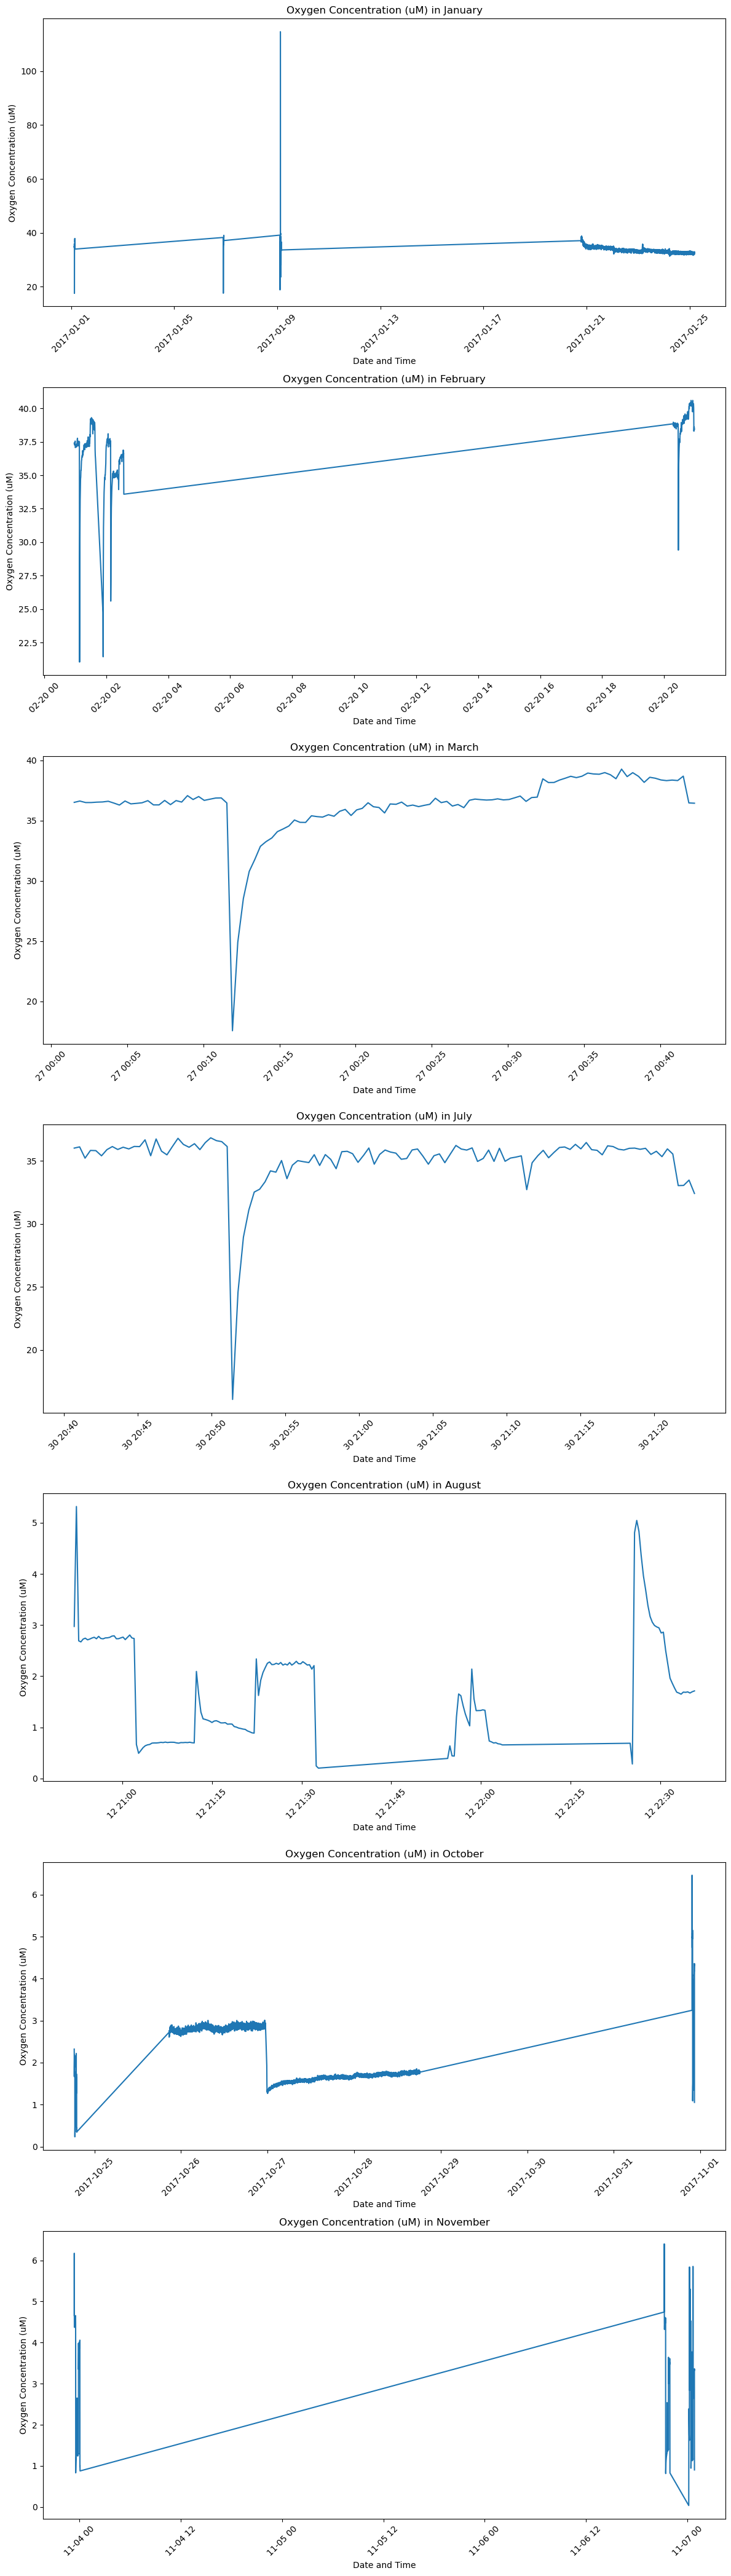

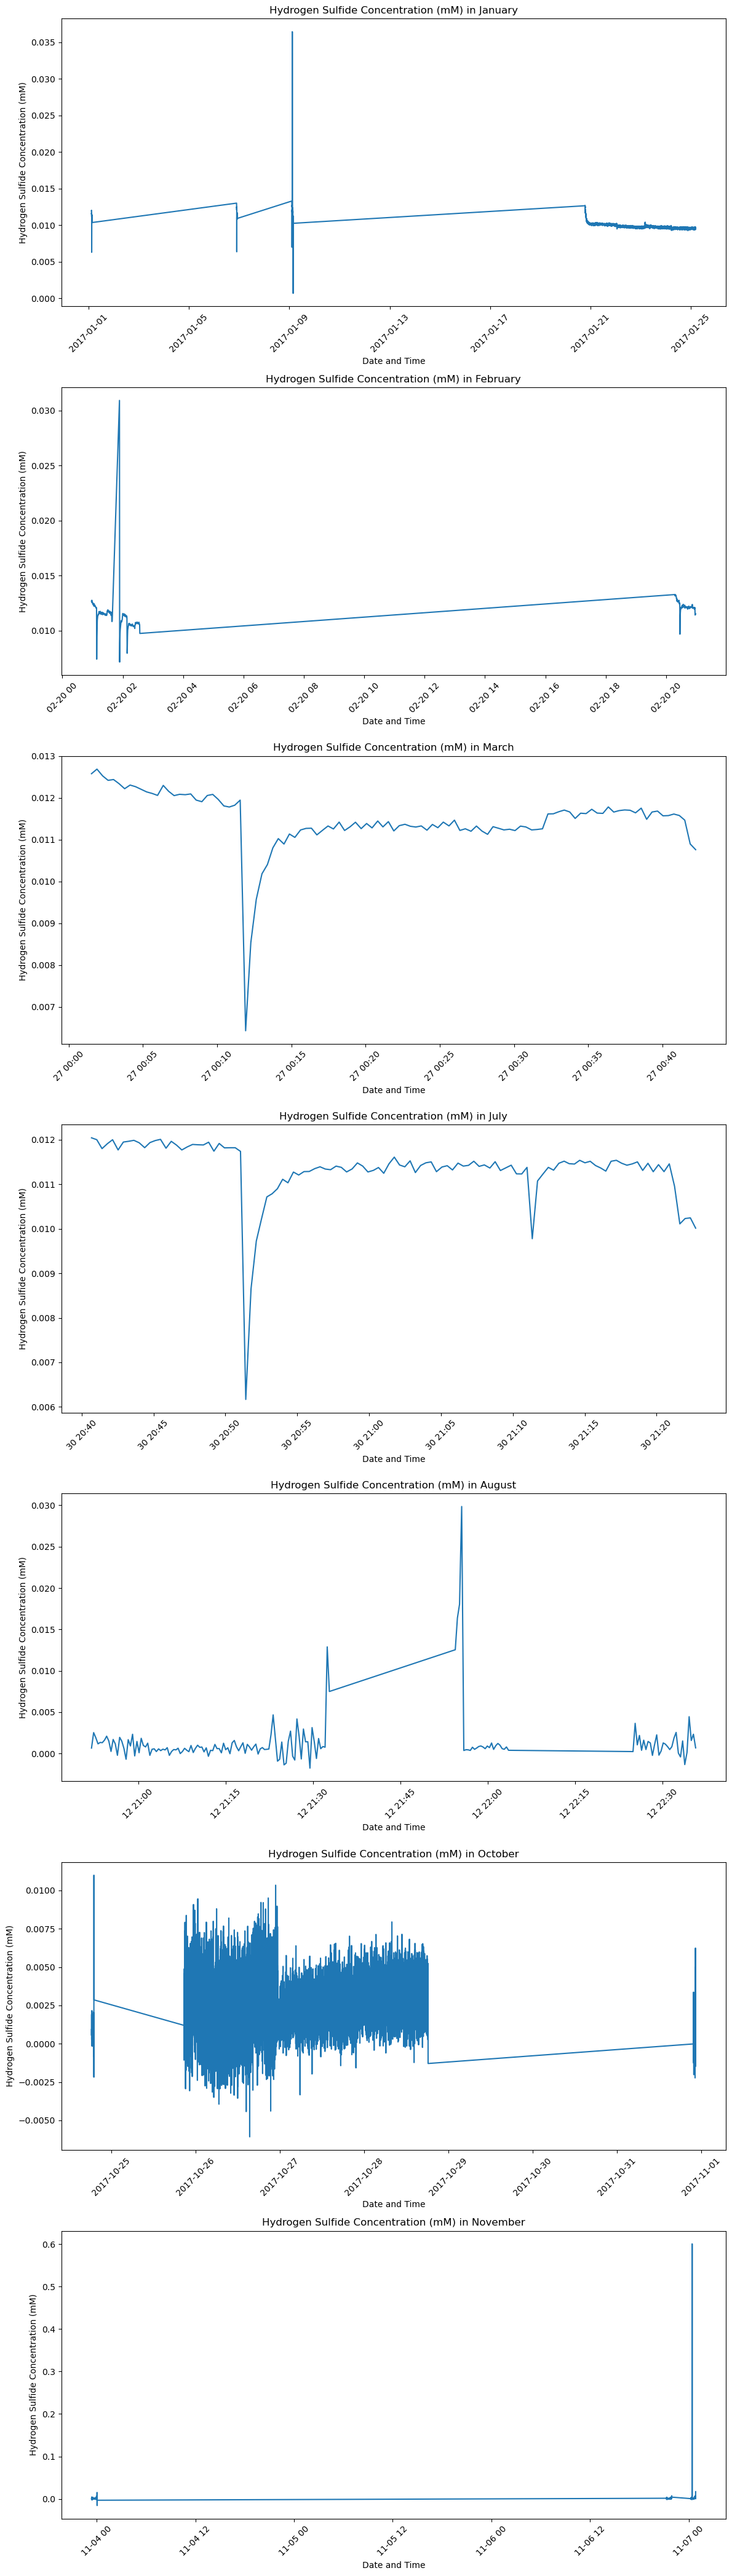

In [10]:
# Figure 3
# Plot each month for which we have data on a separate subplot line plot for each extracted compound

for compound_name, result in compound_results.items():
    new_df = result["dataframe"]
    concentration_col = result["concentration_col"]
    final_unit = result["final_unit"]

    months = new_df['DateTime'].dt.month.unique()
    months.sort()
    num_months = len(months)

    fig, axes = plt.subplots(num_months, 1, figsize=(12, 6 * num_months))

    if num_months == 1:
        axes = [axes]

    for i, month in enumerate(months):
        # Convert month number to month name for title
        month_name = pd.to_datetime(str(month), format='%m').strftime('%B')
        month_data = new_df[new_df['DateTime'].dt.month == month]

        axes[i].plot(month_data['DateTime'], month_data[concentration_col])
        axes[i].set_title(f'{compound_name} Concentration ({final_unit}) in {month_name}')
        axes[i].set_xlabel('Date and Time')
        axes[i].set_ylabel(f'{compound_name} Concentration ({final_unit})')
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

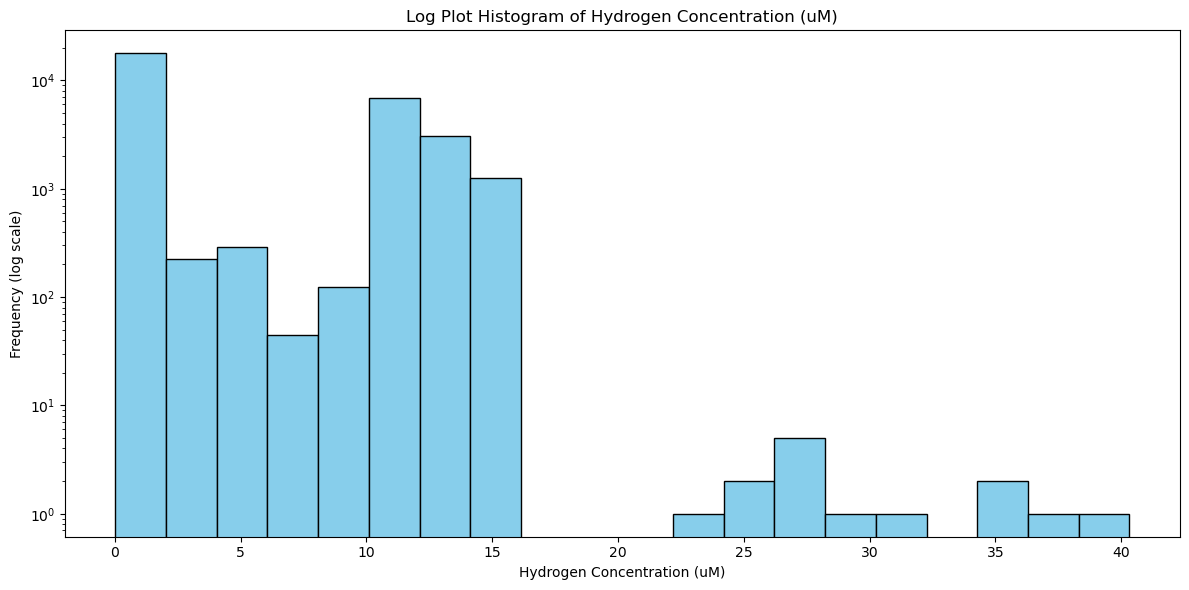

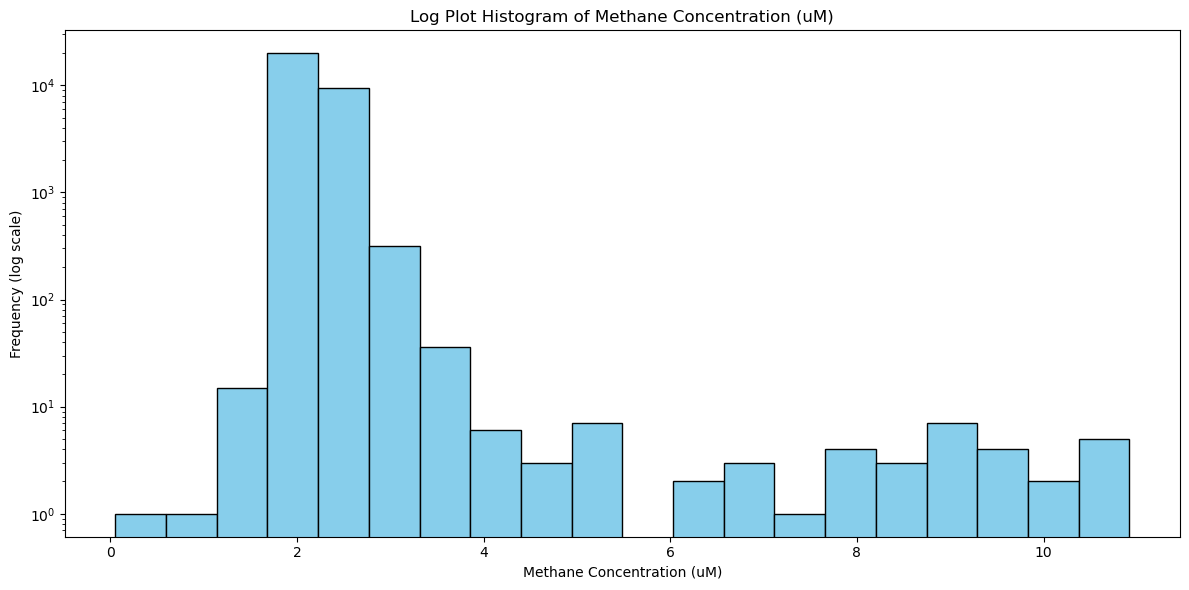

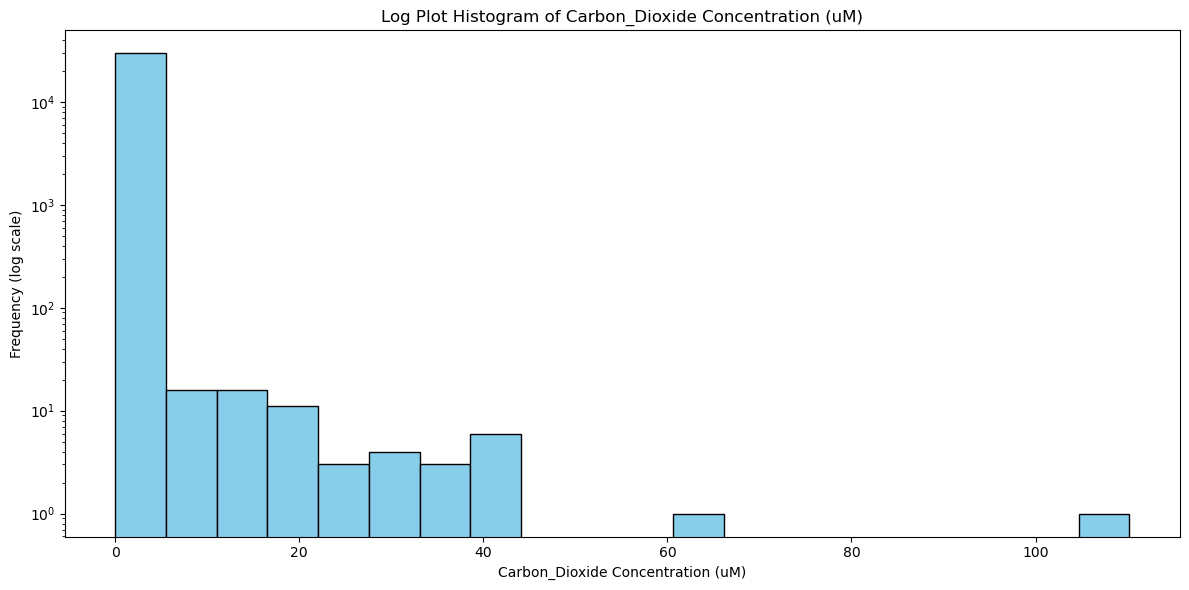

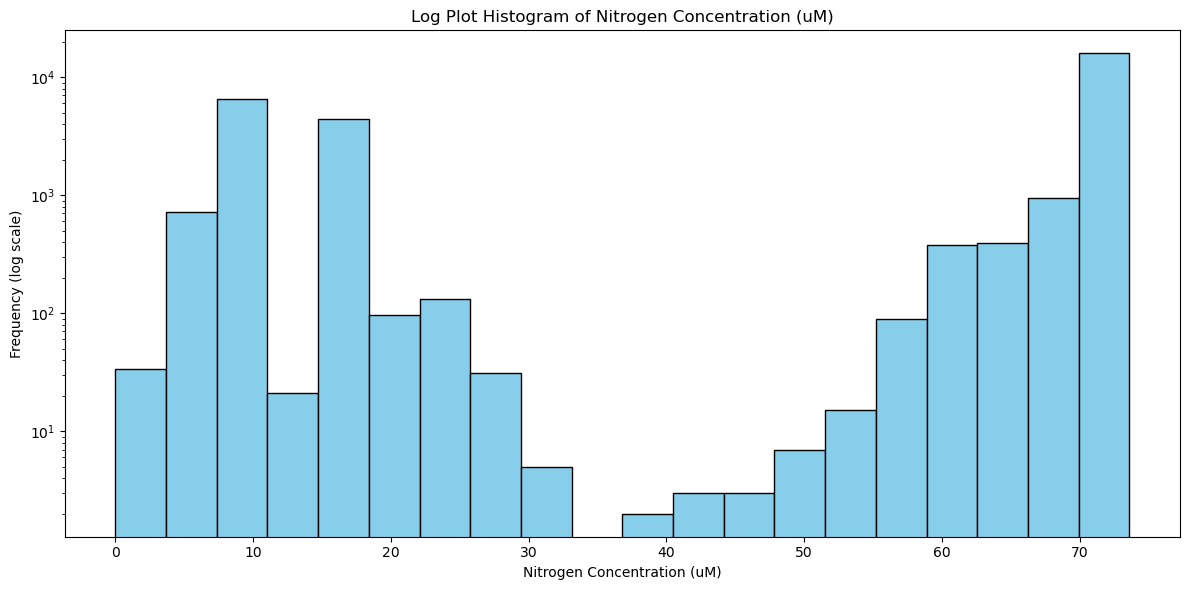

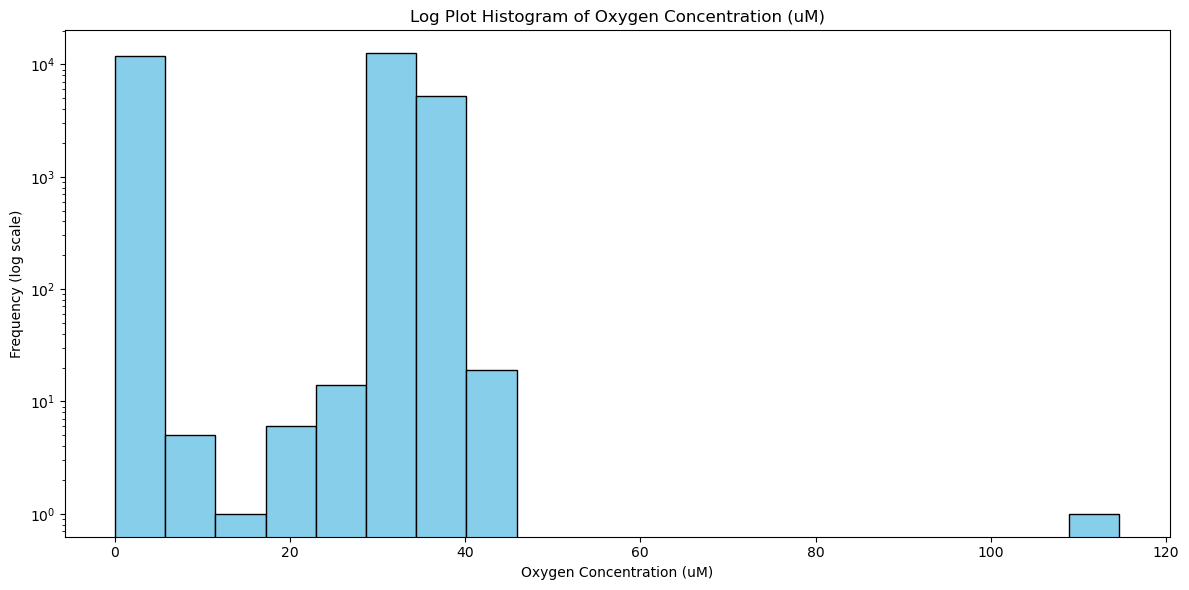

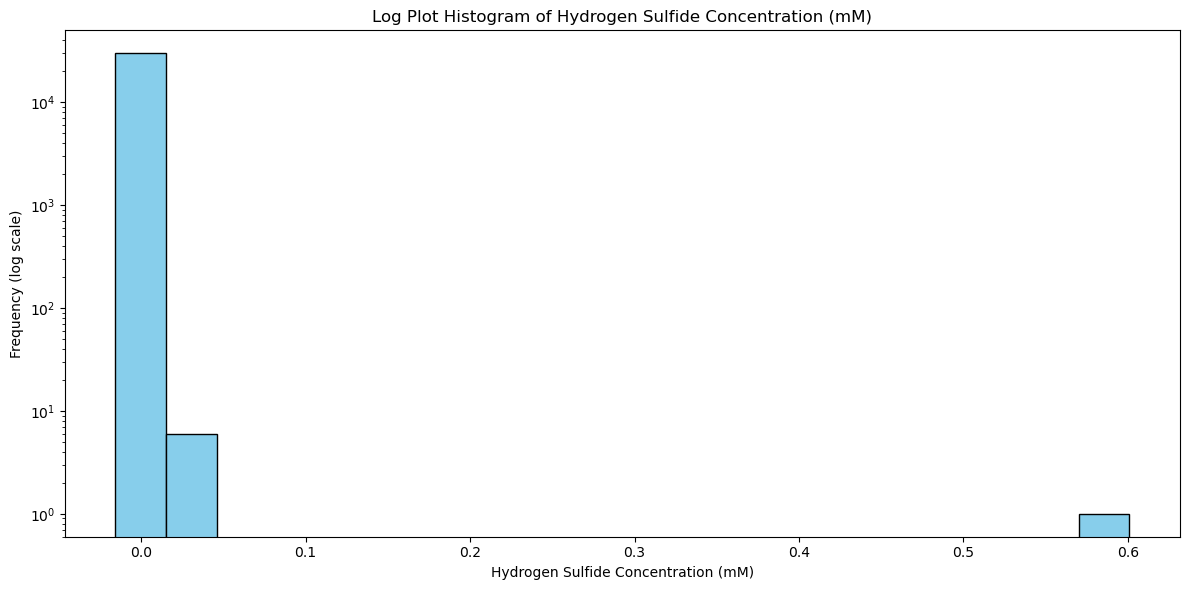

In [11]:
# Figure 4
# Log plot histogram of concentration for each extracted compound

for compound_name, result in compound_results.items():
    new_df = result["dataframe"]
    concentration_col = result["concentration_col"]
    final_unit = result["final_unit"]

    plt.figure(figsize=(12, 6))
    plt.hist(new_df[concentration_col], bins=20, color='skyblue', edgecolor='black')
    plt.yscale('log')
    plt.title(f'Log Plot Histogram of {compound_name} Concentration ({final_unit})')
    plt.xlabel(f'{compound_name} Concentration ({final_unit})')
    plt.ylabel('Frequency (log scale)')
    plt.tight_layout()
    plt.show()

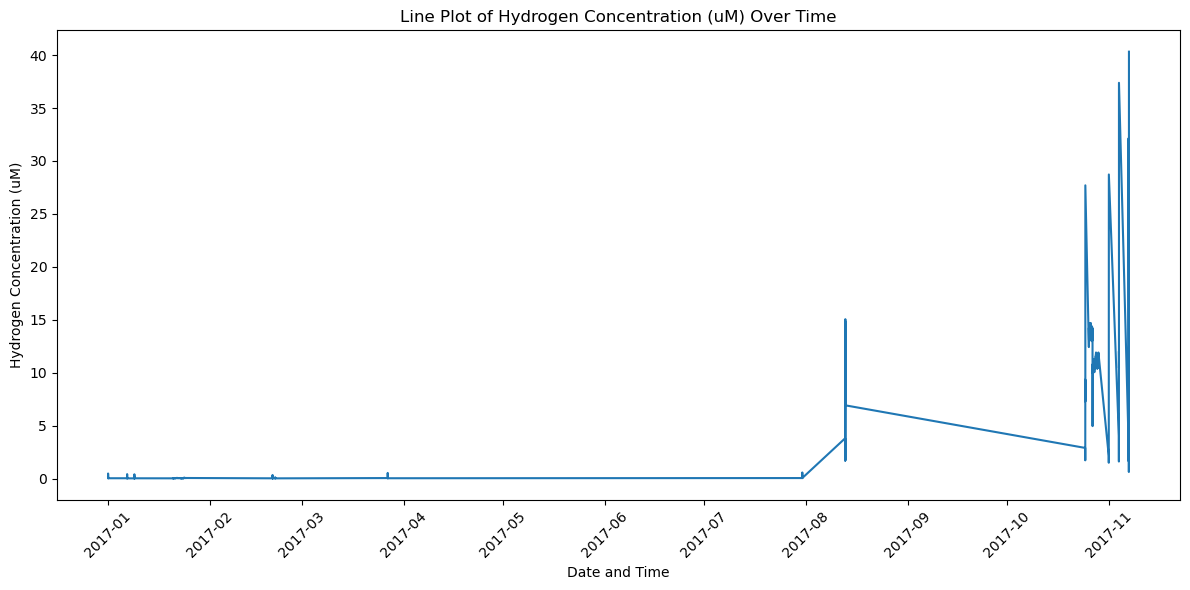

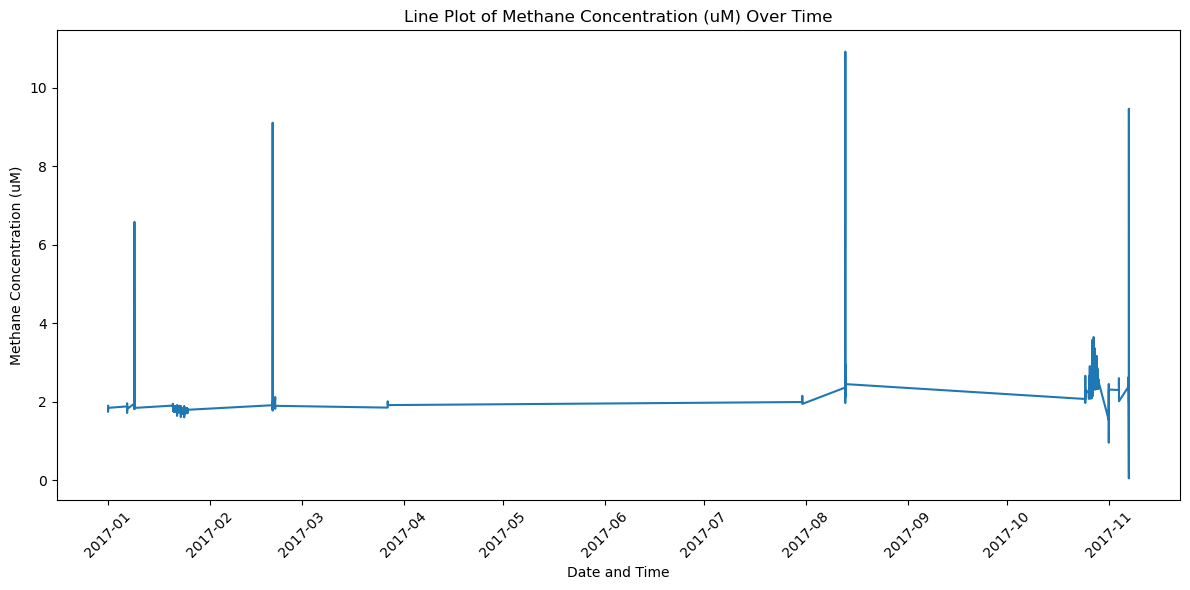

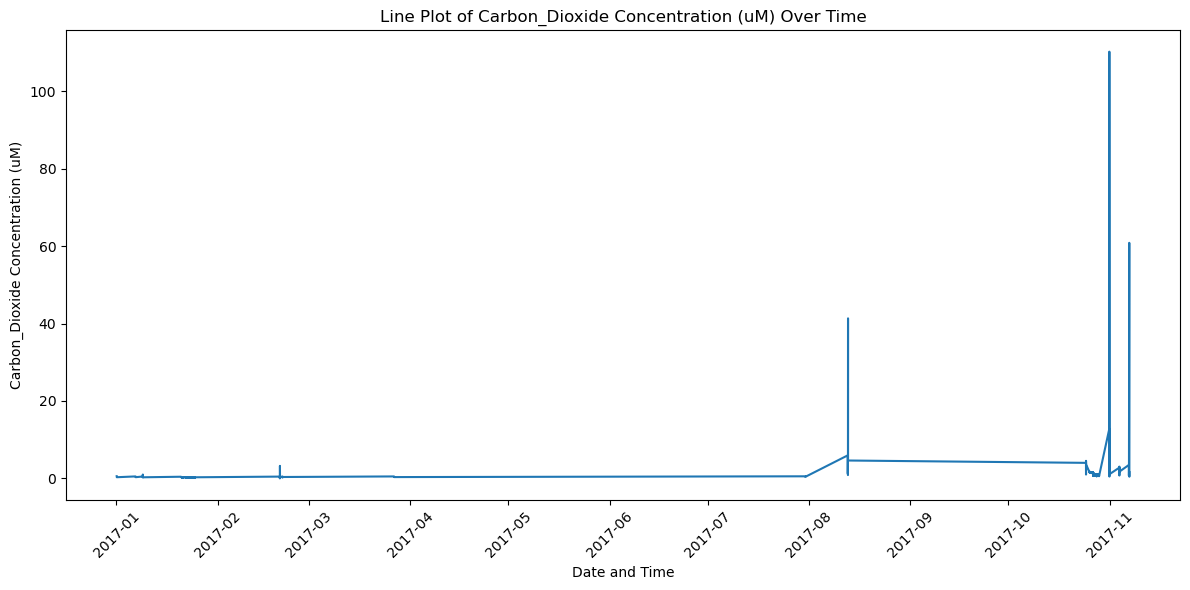

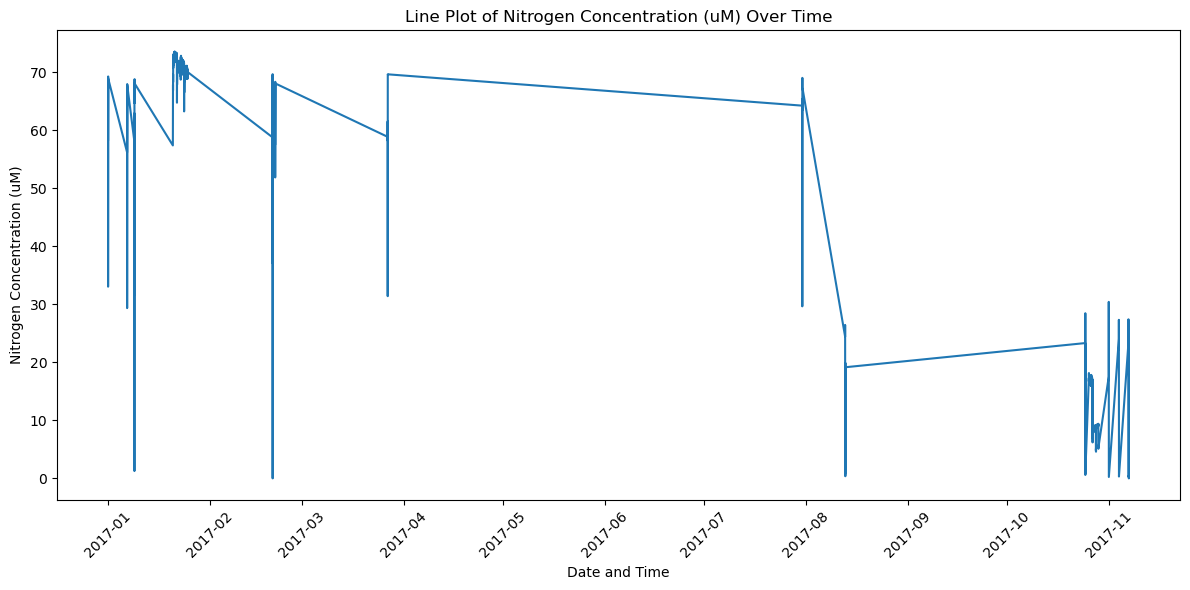

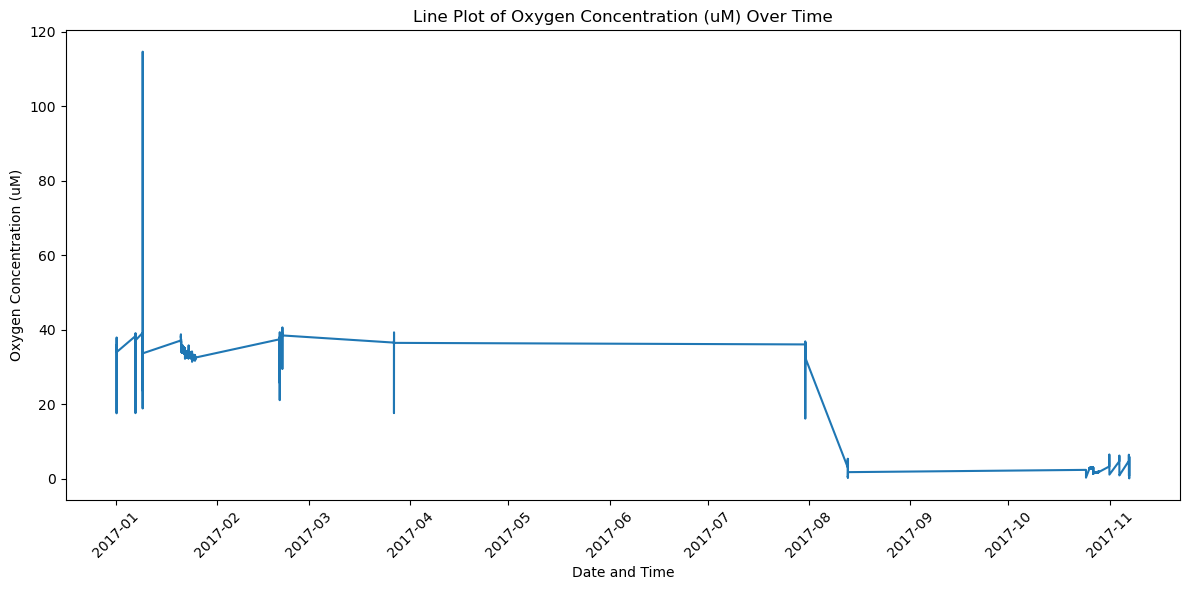

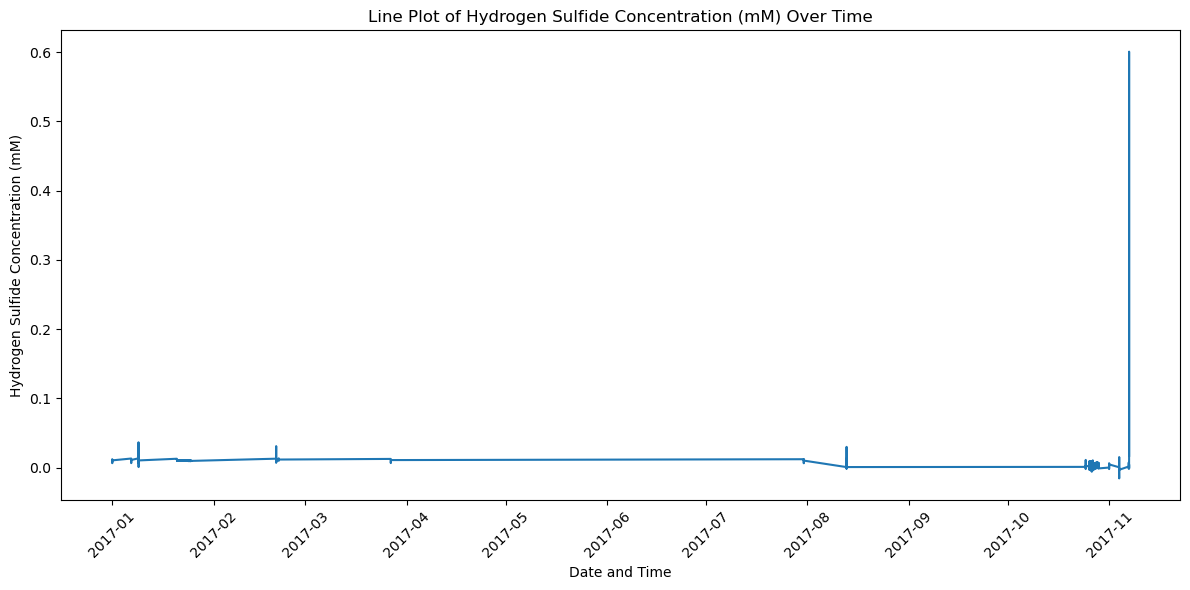

In [12]:
# Figure 5
# Line plot of Date + Time vs. concentration for each extracted compound

for compound_name, result in compound_results.items():
    new_df = result["dataframe"]
    concentration_col = result["concentration_col"]
    final_unit = result["final_unit"]

    plt.figure(figsize=(12, 6))
    plt.plot(new_df['DateTime'], new_df[concentration_col])
    plt.title(f'Line Plot of {compound_name} Concentration ({final_unit}) Over Time')
    plt.xlabel('Date and Time')
    plt.ylabel(f'{compound_name} Concentration ({final_unit})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
# File export
# Save the timestamp and compound concentration columns to new CSV files
# Also save each figure type for each compound with the correct compound name

os.makedirs(FIGURE_OUTPUT_FOLDER, exist_ok=True)

for compound_name, result in compound_results.items():
    new_df = result["dataframe"]
    concentration_col = result["concentration_col"]
    final_unit = result["final_unit"]
    output_csv = result["output_csv"]

    # Export concentration table
    new_df[['Timestamp', concentration_col]].to_csv(output_csv, index=False)

    # Export Figure 1
    plt.figure(figsize=(12, 6))
    plt.boxplot(new_df[concentration_col], vert=False)
    plt.title(f'Box Plot of {compound_name} Concentration ({final_unit})')
    plt.xlabel(f'{compound_name} Concentration ({final_unit})')
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURE_OUTPUT_FOLDER, f'{compound_name.lower()}_figure1_boxplot.png'),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close()

    # Export Figure 2
    plt.figure(figsize=(12, 6))
    plt.scatter(new_df['DateTime'], new_df[concentration_col])

    for i in range(len(new_df) - 1):
        if new_df.iloc[i][concentration_col] > 0 and new_df.iloc[i + 1][concentration_col] > 0:
            plt.axvspan(
                new_df.iloc[i]['DateTime'],
                new_df.iloc[i + 1]['DateTime'],
                alpha=0.2,
                color='lightblue'
            )

    plt.title(f'Scatter Plot of {compound_name} Concentration ({final_unit}) Over Time')
    plt.xlabel('Date and Time')
    plt.ylabel(f'{compound_name} Concentration ({final_unit})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURE_OUTPUT_FOLDER, f'{compound_name.lower()}_figure2_scatter_time_series.png'),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close()

    # Export Figure 3
    months = new_df['DateTime'].dt.month.unique()
    months.sort()
    num_months = len(months)

    fig, axes = plt.subplots(num_months, 1, figsize=(12, 6 * num_months))

    if num_months == 1:
        axes = [axes]

    for i, month in enumerate(months):
        month_name = pd.to_datetime(str(month), format='%m').strftime('%B')
        month_data = new_df[new_df['DateTime'].dt.month == month]

        axes[i].plot(month_data['DateTime'], month_data[concentration_col])
        axes[i].set_title(f'{compound_name} Concentration ({final_unit}) in {month_name}')
        axes[i].set_xlabel('Date and Time')
        axes[i].set_ylabel(f'{compound_name} Concentration ({final_unit})')
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURE_OUTPUT_FOLDER, f'{compound_name.lower()}_figure3_monthly_subplots.png'),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close()

    # Export Figure 4
    plt.figure(figsize=(12, 6))
    plt.hist(new_df[concentration_col], bins=20, color='skyblue', edgecolor='black')
    plt.yscale('log')
    plt.title(f'Log Plot Histogram of {compound_name} Concentration ({final_unit})')
    plt.xlabel(f'{compound_name} Concentration ({final_unit})')
    plt.ylabel('Frequency (log scale)')
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURE_OUTPUT_FOLDER, f'{compound_name.lower()}_figure4_log_histogram.png'),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close()

    # Export Figure 5
    plt.figure(figsize=(12, 6))
    plt.plot(new_df['DateTime'], new_df[concentration_col])
    plt.title(f'Line Plot of {compound_name} Concentration ({final_unit}) Over Time')
    plt.xlabel('Date and Time')
    plt.ylabel(f'{compound_name} Concentration ({final_unit})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURE_OUTPUT_FOLDER, f'{compound_name.lower()}_figure5_line_time_series.png'),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close()

print('All compound CSV files and figure files have been exported.')

All compound CSV files and figure files have been exported.
